In [1]:
## History
## 2024.04.11 First try VisiumHD, using Lily

In [1]:
## pathway
# path = '/Users/lilingyu/E/PhD/Python/'
# path = '/storage3/yhhuang/users/lingyu/'
# path = '/data/users/lingyu/'
# path = '/home/lly/Python/'
# path = '/mnt/lingyu/nfs_share2/Python/'
path = '/home/lingyu/ssd/Python/'

In [2]:
import importlib.util
import sys
import pandas as pd
import numpy as np
import scanpy as sc
import h5py
import scipy
import math
from scipy import sparse, io
from scipy.sparse import csr_matrix

In [12]:
import os
os.chdir(str(path)+'iSTAR/istar-master/data/NPC1/')

## Load expression

In [5]:
# 参数设置
patient = 'GSM6030901_patient_1_'
patientxy = 'patient1'
result = 'P1result'
spot_diameter_fullres=139.44595843130838

In [6]:
## 读入hdf5格式文件
import h5py
f = h5py.File(str(patient)+'filtered_feature_bc_matrix.h5', 'r')
print(f.keys())

<KeysViewHDF5 ['matrix']>


In [7]:
## 获取cell mate信息
cell_mate = f['matrix']['barcodes']
cell_mate = pd.DataFrame(cell_mate)
cell_mate.head()

,0
0,b'AAACAATCTACTAGCA-1'
1,b'AAACGAAGAACATACC-1'
2,b'AAAGGGATGTAGCAAG-1'
3,b'AAAGTCACTGATGTAA-1'
4,b'AAAGTGTGATTTATCT-1'


In [8]:
## 提取基因信息
gene_df = f['matrix']['features']['name'][()]
gene_df = pd.DataFrame(gene_df)
gene_df.head()

,0
0,b'MIR1302-2HG'
1,b'FAM138A'
2,b'OR4F5'
3,b'AL627309.1'
4,b'AL627309.3'


In [9]:
## 提取表达谱, 表达谱以稀疏矩阵的形式存放
data = f['matrix']['data']
print(data)
indices = f['matrix']['indices']
print(indices)
indptr = f['matrix']['indptr']
print(indptr)

<HDF5 dataset "data": shape (4347024,), type "<i4">
<HDF5 dataset "indices": shape (4347024,), type "<i8">
<HDF5 dataset "indptr": shape (1332,), type "<i8">


In [10]:
## 得到 matrix 矩阵
matrix = csr_matrix((data, indices, indptr))
print(matrix.shape)
matrix1 = pd.DataFrame(matrix.todense())
matrix1

(1331, 36601)


,0,1,2,3,4,5,6,7,8,9,...,36591,36592,36593,36594,36595,36596,36597,36598,36599,36600
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1326,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1327,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1328,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1329,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [11]:
## 获取 barcode
cellID = cell_mate[0].tolist()

## 将 bates 文件解码
for i in range(len(cellID)):
    cellID[i] = cellID[i].decode(encoding='ascii')

In [12]:
## 获取 geneSymbol
genes = gene_df[0].tolist()
for i in range(len(genes)):
    genes[i] = genes[i].decode(encoding='ascii')

In [13]:
matrix1.columns = genes  # 列重命名
matrix1.insert(0, 'cellID', cellID)  # 插入cellID
matrix1.head()

,cellID,MIR1302-2HG,FAM138A,OR4F5,AL627309.1,AL627309.3,AL627309.2,AL627309.5,AL627309.4,AP006222.2,...,AC133551.1,AC136612.1,AC136616.1,AC136616.3,AC136616.2,AC141272.1,AC023491.2,AC007325.1,AC007325.4,AC007325.2
0,AAACAATCTACTAGCA-1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,AAACGAAGAACATACC-1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,AAAGGGATGTAGCAAG-1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,AAAGTCACTGATGTAA-1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,AAAGTGTGATTTATCT-1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [14]:
## save h5 to tsv
# matrix1.to_csv('cnts.tsv', sep='\t', index=False)

## Load position
position的行与matrix的行，不对齐

In [15]:
position = pd.read_csv('tissue_positions.csv', header=None)
position

,0,1,2,3,4,5
0,GTGTGAGCCGAGGTGC-1,1,1,33,1612,5423
1,GGGAACCACCTGTTTC-1,1,1,35,1613,5638
2,GTTCGTTGCGGACCAG-1,1,0,36,1426,5745
3,TGAGGTTGATCCCAAG-1,1,1,37,1613,5852
4,GATGCCACACTACAGC-1,1,0,38,1427,5960
...,...,...,...,...,...,...
1326,TTCGACAGAGCCCGTG-1,1,52,68,11140,9153
1327,AAGCATACTCTCCTGA-1,1,53,69,11327,9260
1328,GACGACGATCCGCGTT-1,1,52,70,11141,9368
1329,GGTAGAAGACCGCCTG-1,1,53,71,11328,9474


In [16]:
position.rename(columns={0: 'cellID'}, inplace=True)
sorted_position = matrix1[['cellID']].merge(position, on='cellID', how='left')
sorted_position.rename(columns={'cellID': 0}, inplace=True)
position = sorted_position
position

,0,1,2,3,4,5
0,AAACAATCTACTAGCA-1,1,3,43,1988,6495
1,AAACGAAGAACATACC-1,1,6,64,2554,8746
2,AAAGGGATGTAGCAAG-1,1,24,62,5913,8523
3,AAAGTCACTGATGTAA-1,1,10,52,3297,7457
4,AAAGTGTGATTTATCT-1,1,44,94,9654,11946
...,...,...,...,...,...,...
1326,TTGTGGCCCTGACAGT-1,1,18,60,4792,8311
1327,TTGTGTTTCCCGAAAG-1,1,51,59,10951,8188
1328,TTGTTAGCAAATTCGA-1,1,22,42,5534,6378
1329,TTGTTCAGTGTGCTAC-1,1,24,64,5913,8737


In [17]:
## need reverse the order
position_save = position[[0, 5, 4]]
position_save.columns = ["spot", "x", "y"]
position_save

,spot,x,y
0,AAACAATCTACTAGCA-1,6495,1988
1,AAACGAAGAACATACC-1,8746,2554
2,AAAGGGATGTAGCAAG-1,8523,5913
3,AAAGTCACTGATGTAA-1,7457,3297
4,AAAGTGTGATTTATCT-1,11946,9654
...,...,...,...
1326,TTGTGGCCCTGACAGT-1,8311,4792
1327,TTGTGTTTCCCGAAAG-1,8188,10951
1328,TTGTTAGCAAATTCGA-1,6378,5534
1329,TTGTTCAGTGTGCTAC-1,8737,5913


In [18]:
## save csv to tsv
# position_save.to_csv('locs-raw.tsv', sep='\t', index=False)

## Change ij coordinates to xy coordinates

In [30]:
def get_locs(prefix, target_shape=None):

    locs = load_tsv(f'{prefix}locs.tsv')

    # change xy coordinates to ij coordinates
    locs = np.stack([locs['y'], locs['x']], -1)

    # match coordinates of embeddings and spot locations
    if target_shape is not None:
        wsi = load_image(f'{prefix}he.jpg')
        current_shape = np.array(wsi.shape[:2])
        rescale_factor = current_shape // target_shape
        locs = locs.astype(float)
        locs /= rescale_factor

    # find the nearest pixel
    locs = locs.round().astype(int)

    return locs

import pickle
def load_pickle(filename, verbose=True):
    with open(filename, 'rb') as file:
        x = pickle.load(file)
    if verbose:
        print(f'Pickle loaded from {filename}')
    return x

In [31]:
embs = load_pickle('embeddings-hist.pickle')
# print("embs:", embs)
embs = np.concatenate([embs['cls'], embs['sub'], embs['rgb']])
embs = embs.transpose(1, 2, 0)
print("embs shape:\n", embs.shape)
target_shape=embs.shape[:2]
print("target_shape:\n", target_shape) # (544, 544)

Pickle loaded from embeddings-hist.pickle
embs shape:
 (544, 544, 579)
target_shape:
 (544, 544)


In [32]:
994/16 

62.125

In [33]:
## get_locs() input oruginal xy coords, output xy/16 coords
## 16 is the results of image size/embs size, ie 8704/554

locs = load_tsv('locs.tsv')
print("locs:\n", locs)

## change xy coordinates to ij coordinates
locs = np.stack([locs['y'], locs['x']], -1)
print("locs:\n", locs)

## match coordinates of embeddings and spot locations
wsi = load_image('he.jpg')
print('wsi shape:', wsi.shape)
current_shape = np.array(wsi.shape[:2])     
print("current_shape:", current_shape)    # [8704 8704]

rescale_factor = current_shape // target_shape   # array([16, 16]) 
locs = locs.astype(float)
locs /= rescale_factor
print("locs:\n", locs)

# find the nearest pixel
locs = locs.round().astype(int)
print("locs:\n", locs)
print("locsshape:", locs.shape)

Dataframe loaded from locs.tsv
locs:
                        x     y
spot                          
AAACAATCTACTAGCA-1  3248   994
AAACGAAGAACATACC-1  4373  1277
AAAGGGATGTAGCAAG-1  4262  2956
AAAGTCACTGATGTAA-1  3728  1648
AAAGTGTGATTTATCT-1  5973  4827
...                  ...   ...
TTGTGGCCCTGACAGT-1  4156  2396
TTGTGTTTCCCGAAAG-1  4094  5476
TTGTTAGCAAATTCGA-1  3189  2767
TTGTTCAGTGTGCTAC-1  4368  2956
TTGTTTGTGTAAATTC-1  3676  1368

[1331 rows x 2 columns]
locs:
 [[ 994 3248]
 [1277 4373]
 [2956 4262]
 ...
 [2767 3189]
 [2956 4368]
 [1368 3676]]
Image loaded from he.jpg
wsi shape: (8704, 8704, 3)
current_shape: [8704 8704]
locs:
 [[ 62.125  203.    ]
 [ 79.8125 273.3125]
 [184.75   266.375 ]
 ...
 [172.9375 199.3125]
 [184.75   273.    ]
 [ 85.5    229.75  ]]
locs:
 [[ 62 203]
 [ 80 273]
 [185 266]
 ...
 [173 199]
 [185 273]
 [ 86 230]]
locsshape: (1331, 2)


In [34]:
def patchify(x, patch_size):
    shape_ori = np.array(x.shape[:2])
    shape_ext = (
            (shape_ori + patch_size - 1)
            // patch_size * patch_size)
    x = np.pad(
            x,
            (
                (0, shape_ext[0] - x.shape[0]),
                (0, shape_ext[1] - x.shape[1]),
                (0, 0)),
            mode='edge')
    tiles_shape = np.array(x.shape[:2]) // patch_size
    # x = rearrange(
    #         x, '(h1 h) (w1 w) c -> h1 w1 h w c',
    #         h=patch_size, w=patch_size)
    # x = rearrange(
    #         x, '(h1 h) (w1 w) c -> (h1 w1) h w c',
    #         h=patch_size, w=patch_size)
    tiles = []
    for i0 in range(tiles_shape[0]):
        a0 = i0 * patch_size  # TODO: change to patch_size[0]
        b0 = a0 + patch_size  # TODO: change to patch_size[0]
        for i1 in range(tiles_shape[1]):
            a1 = i1 * patch_size  # TODO: change to patch_size[1]
            b1 = a1 + patch_size  # TODO: change to patch_size[1]
            tiles.append(x[a0:b0, a1:b1])

    shapes = dict(
            original=shape_ori,
            padded=shape_ext,
            tiles=tiles_shape)
    return tiles, shapes

In [35]:
12288/4096

3.0

In [36]:
(8704+4096-1)//(4096**2)

0

In [38]:
tile_size = 4096
patch_size=tile_size
shape_ori = np.array(wsi.shape[:2])
print("shape_ori:", shape_ori)


## 校正shape_ori，使得能被整除
shape_ext = (
        (shape_ori + patch_size - 1)
        // patch_size * patch_size)
print("shape_ext:", shape_ext)    # [12288, 12288]

x = np.pad(
        wsi,
        (
            (0, shape_ext[0] - wsi.shape[0]),
            (0, shape_ext[1] - wsi.shape[1]),
            (0, 0)),
        mode='edge')
# print("x shape:", x)
print("x shape:", x.shape)

tiles_shape = np.array(x.shape[:2]) // patch_size
print("tiles_shape shape:", tiles_shape.shape)
print("tiles_shape[0]:", tiles_shape)

tiles = []
for i0 in range(tiles_shape[0]):
    a0 = i0 * patch_size  
    b0 = a0 + patch_size  
    for i1 in range(tiles_shape[1]):
        a1 = i1 * patch_size 
        b1 = a1 + patch_size  
        tiles.append(x[a0:b0, a1:b1])
print("tiles shape:", len(tiles))
# shapes = dict(
#         original=shape_ori,
#         padded=shape_ext,
#         tiles=tiles_shape)
# return tiles, shapes

shape_ori: [8704 8704]
shape_ext: [12288 12288]
x shape: (12288, 12288, 3)
tiles_shape shape: (2,)
tiles_shape[0]: [3 3]
tiles shape: 9


In [39]:
print(shape_ori + patch_size - 1)
print(patch_size)
print((shape_ori + patch_size - 1)// patch_size)
print(patch_size * patch_size)
print((shape_ori + patch_size - 1)// patch_size * patch_size)
(shape_ori + patch_size - 1)// patch_size * patch_size

[12799 12799]
4096
[3 3]
16777216
[12288 12288]


array([12288, 12288])

In [40]:
8704/16

544.0

## Load iputated data

In [41]:
import os
os.chdir(str(path)+'iSTAR/istar-master/data/NPC1/')

## Load imputed data of each gene

In [42]:
## https://github.com/daviddaiweizhang/istar/blob/master/plot_imputed.py#L42
def read_lines(filename):
    with open(filename, 'r') as file:
        lines = [line.rstrip() for line in file]
    return lines

import pickle
def load_pickle(filename, verbose=True):
    with open(filename, 'rb') as file:
        x = pickle.load(file)
    if verbose:
        print(f'Pickle loaded from {filename}')
    return x

In [43]:
gene_names = read_lines('gene-names.txt')
gene_names

['TGFB1',
 'TGFBR1',
 'TGFBR2',
 'TGFB2',
 'TGFB3',
 'ACVR1B',
 'ACVR1C',
 'ACVR1',
 'BMP2',
 'BMPR1A',
 'ACVR2A',
 'ACVR2B',
 'BMPR2',
 'BMP4',
 'GDF7',
 'BMP6',
 'BMP7',
 'BMP8A',
 'BMP8B',
 'ACVRL1',
 'GDF11',
 'GDF15',
 'AMH',
 'GFRA1',
 'NRTN',
 'GFRA2',
 'ARTN',
 'PSPN',
 'INHBA',
 'INHBB',
 'WNT1',
 'FZD1',
 'LRP5',
 'FZD10',
 'FZD2',
 'FZD3',
 'FZD4',
 'FZD5',
 'FZD6',
 'FZD7',
 'FZD8',
 'WNT10A',
 'WNT10B',
 'WNT2',
 'WNT3A',
 'WNT4',
 'WNT6',
 'WNT7B',
 'LRP6',
 'WNT5A',
 'MCAM',
 'WNT5B',
 'EGFR',
 'ERBB2',
 'TGFA',
 'AREG',
 'BTC',
 'HBEGF',
 'NRG1',
 'ERBB3',
 'NRG2',
 'ITGAV',
 'FGF1',
 'FGFR1',
 'FGFR2',
 'FGFR3',
 'FGF2',
 'FGF7',
 'FGF20',
 'PDGFA',
 'PDGFRA',
 'PDGFRB',
 'PDGFB',
 'PDGFC',
 'PDGFD',
 'VEGFA',
 'VEGFB',
 'VEGFC',
 'PGF',
 'IGF1',
 'IGF1R',
 'IGF2R',
 'ITGA6',
 'ITGB4',
 'IGFLR1',
 'APLN',
 'APLNR',
 'PTCH1',
 'PTCH2',
 'CCL5',
 'CCR1',
 'CCL3',
 'CCL3L1',
 'CCL8',
 'CCL13',
 'CCL14',
 'CCL15',
 'CCR2',
 'CCL2',
 'CCL11',
 'CCL26',
 'CCL28',
 'CCL17',
 

In [44]:
for gn in gene_names:
    cnts = load_pickle('cnts-super/'+str(gn)+'.pickle')

Pickle loaded from cnts-super/TGFB1.pickle
Pickle loaded from cnts-super/TGFBR1.pickle
Pickle loaded from cnts-super/TGFBR2.pickle
Pickle loaded from cnts-super/TGFB2.pickle
Pickle loaded from cnts-super/TGFB3.pickle
Pickle loaded from cnts-super/ACVR1B.pickle
Pickle loaded from cnts-super/ACVR1C.pickle
Pickle loaded from cnts-super/ACVR1.pickle
Pickle loaded from cnts-super/BMP2.pickle
Pickle loaded from cnts-super/BMPR1A.pickle
Pickle loaded from cnts-super/ACVR2A.pickle
Pickle loaded from cnts-super/ACVR2B.pickle
Pickle loaded from cnts-super/BMPR2.pickle
Pickle loaded from cnts-super/BMP4.pickle
Pickle loaded from cnts-super/GDF7.pickle
Pickle loaded from cnts-super/BMP6.pickle
Pickle loaded from cnts-super/BMP7.pickle
Pickle loaded from cnts-super/BMP8A.pickle
Pickle loaded from cnts-super/BMP8B.pickle
Pickle loaded from cnts-super/ACVRL1.pickle
Pickle loaded from cnts-super/GDF11.pickle
Pickle loaded from cnts-super/GDF15.pickle
Pickle loaded from cnts-super/AMH.pickle
Pickle loa

In [45]:
import pandas as pd
pd.DataFrame(cnts)

,0,1,2,3,4,5,6,7,8,9,...,534,535,536,537,538,539,540,541,542,543
0,0.001385,0.001383,0.001373,0.001374,0.001370,0.001403,0.001456,0.001475,0.001514,0.001556,...,0.001860,0.001926,0.002001,0.002002,0.002002,0.002002,0.002002,0.002004,0.002004,0.002004
1,0.001356,0.001337,0.001329,0.001318,0.001313,0.001374,0.001419,0.001448,0.001495,0.001544,...,0.001856,0.001923,0.002001,0.002001,0.002002,0.002002,0.002002,0.002004,0.002004,0.002004
2,0.001326,0.001304,0.001294,0.001276,0.001293,0.001343,0.001369,0.001398,0.001441,0.001502,...,0.001853,0.001921,0.002001,0.002001,0.002001,0.002001,0.002002,0.002004,0.002004,0.002004
3,0.001294,0.001257,0.001240,0.001277,0.001339,0.001383,0.001445,0.001488,0.001538,0.001621,...,0.001850,0.001918,0.002001,0.002001,0.002002,0.002001,0.002001,0.002004,0.002004,0.002004
4,0.001256,0.001211,0.001236,0.001309,0.001363,0.001427,0.001504,0.001549,0.001637,0.001704,...,0.001847,0.001915,0.002001,0.002001,0.002002,0.002002,0.002001,0.002004,0.002004,0.002004
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
539,0.002002,0.002001,0.002002,0.002001,0.002001,0.002001,0.002001,0.002001,0.002001,0.002001,...,0.002001,0.002001,0.002001,0.002002,0.002002,0.002002,0.002002,0.002004,0.002004,0.002004
540,0.002001,0.002002,0.002001,0.002001,0.002002,0.002001,0.002002,0.002001,0.002001,0.002001,...,0.002001,0.002001,0.002001,0.002001,0.002002,0.002002,0.002001,0.002004,0.002004,0.002004
541,0.002002,0.002001,0.002002,0.002001,0.002001,0.002002,0.002002,0.002001,0.002002,0.002002,...,0.002001,0.002001,0.002001,0.002001,0.002001,0.002001,0.002001,0.002004,0.002004,0.002004
542,0.002004,0.002004,0.002004,0.002004,0.002004,0.002004,0.002004,0.002004,0.002004,0.002004,...,0.002004,0.002004,0.002004,0.002004,0.002004,0.002004,0.002004,0.002004,0.002004,0.002004


In [46]:
import numpy as np
from PIL import Image
Image.MAX_IMAGE_PIXELS = None


def load_image(filename, verbose=True):
    img = Image.open(filename)
    img = np.array(img)
    if img.ndim == 3 and img.shape[-1] == 4:
        img = img[..., :3]  # remove alpha channel
    if verbose:
        print(f'Image loaded from {filename}')
    return img

In [47]:
mask = load_image('mask-small.png') > 0
mask

Image loaded from mask-small.png


array([[False, False, False, ..., False, False, False],
       [False, False, False, ..., False, False, False],
       [False, False, False, ..., False, False, False],
       ...,
       [False, False, False, ..., False, False, False],
       [False, False, False, ..., False, False, False],
       [False, False, False, ..., False, False, False]])

In [48]:
# for gn in gene_names:
#     cnts = load_pickle('cnts-super/'+str(gn)+'.pickle')
#     cnts[~mask] = np.nan
# pd.DataFrame(cnts)

In [49]:
gene_names[0]

'TGFB1'

In [143]:
# gn = gene_names[0]
gn = 'CD70'
cnts = load_pickle('cnts-super/'+str(gn)+'.pickle')
cnts[~mask] = np.nan
pd.DataFrame(cnts)

Pickle loaded from cnts-super/CD70.pickle


,0,1,2,3,4,5,6,7,8,9,...,534,535,536,537,538,539,540,541,542,543
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
539,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
540,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
541,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
542,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [144]:
x = cnts.copy()
print(x)
mask = np.isfinite(x)
x -= np.nanmin(x)
x /= np.nanmax(x) + 1e-12
print(x)

[[nan nan nan ... nan nan nan]
 [nan nan nan ... nan nan nan]
 [nan nan nan ... nan nan nan]
 ...
 [nan nan nan ... nan nan nan]
 [nan nan nan ... nan nan nan]
 [nan nan nan ... nan nan nan]]
[[nan nan nan ... nan nan nan]
 [nan nan nan ... nan nan nan]
 [nan nan nan ... nan nan nan]
 ...
 [nan nan nan ... nan nan nan]
 [nan nan nan ... nan nan nan]
 [nan nan nan ... nan nan nan]]


In [145]:
print(x.shape)
x

(544, 544)


array([[nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       ...,
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan]], dtype=float32)

In [146]:
import matplotlib.pyplot as plt
cmap = plt.get_cmap('turbo')
img = cmap(x)[..., :3]
print(len(img))
img[~mask] = 1.0
img = (img * 255).astype(np.uint8)
print(len(img))

544
544


In [147]:
img.shape

(544, 544, 3)

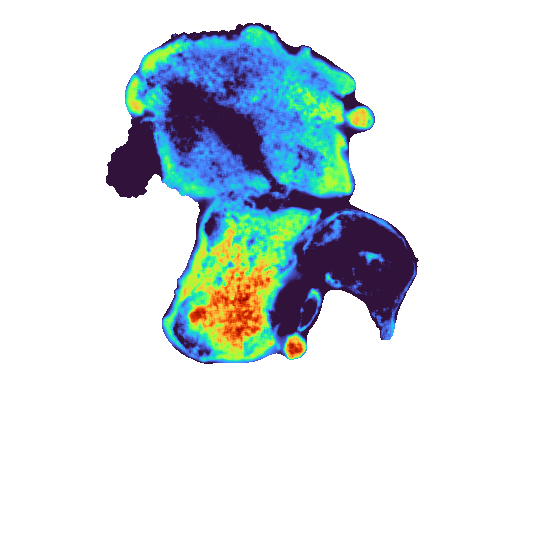

In [148]:
Image.fromarray(img)

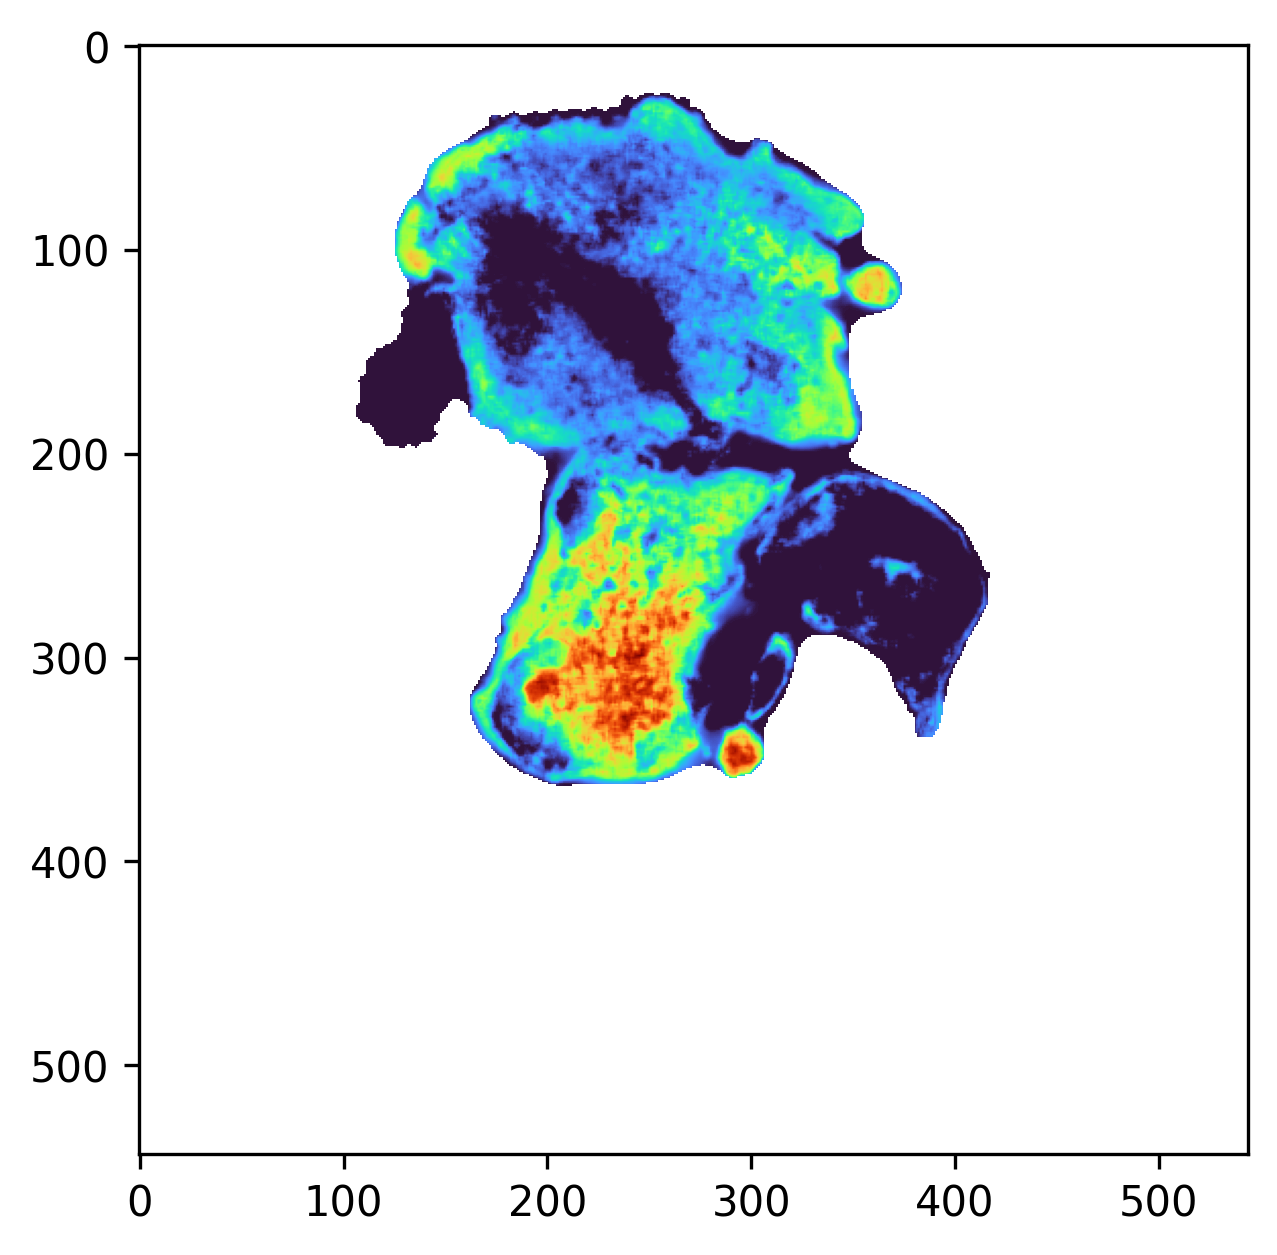

In [149]:
plt.imshow(x, cmap='turbo')
plt.gcf().set_dpi(300)
# plt.savefig(str(gn)+"expression_istar.pdf", format="pdf")
plt.show()

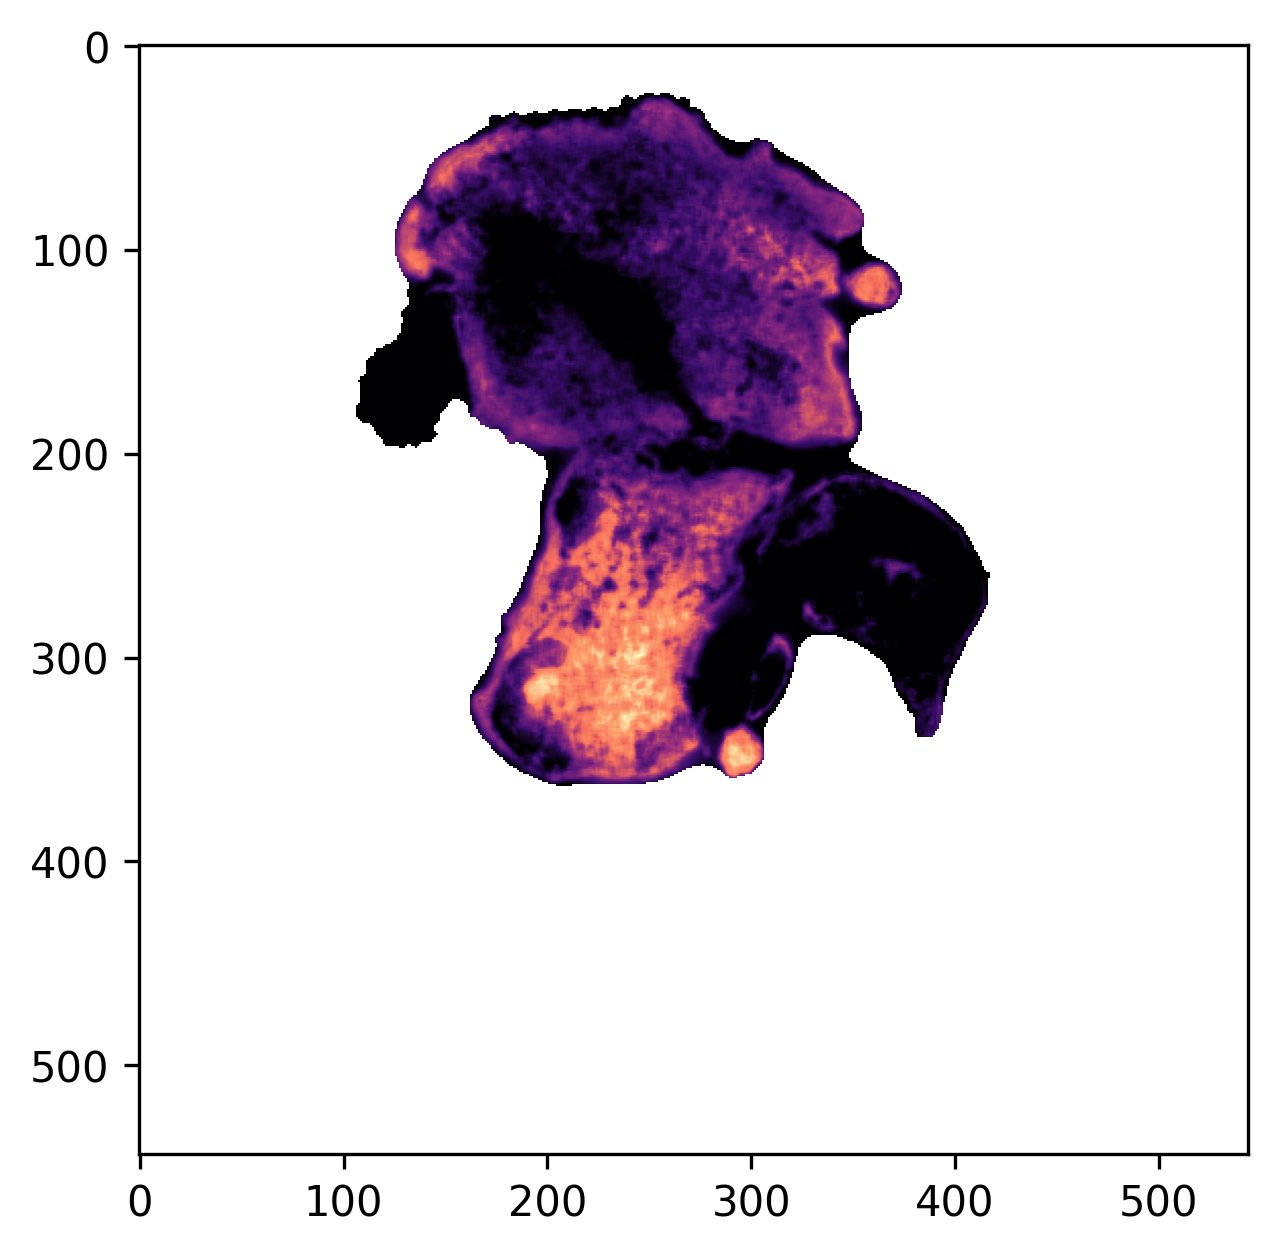

In [153]:
import matplotlib.colors as clr
cnt_color = clr.LinearSegmentedColormap.from_list('magma', ["#000003",  "#3b0f6f",  "#8c2980",   "#f66e5b", "#fd9f6c", "#fbfcbf"], N=256)

plt.imshow(x, cmap=cnt_color)
plt.gcf().set_dpi(300)
# plt.savefig(str(gn)+"expression_istar.pdf", format="pdf")
plt.show()

In [150]:
print(pd.DataFrame(x).shape[0]**2)
print(pd.DataFrame(x).isnull().values.sum())
pd.DataFrame(x)
# pd.DataFrame(x).to_csv(str(gn)+"expression_544.csv", index=True, header=True)

295936
229496


,0,1,2,3,4,5,6,7,8,9,...,534,535,536,537,538,539,540,541,542,543
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
539,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
540,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
541,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
542,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


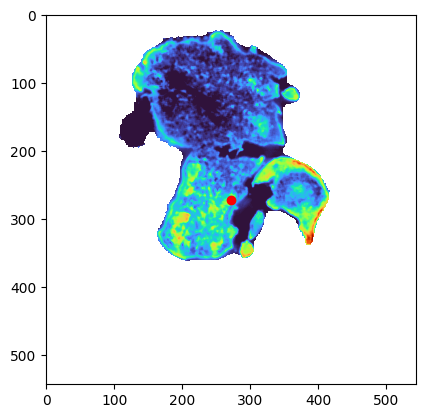

In [58]:
plt.imshow(x, cmap='turbo')
center_x = x.shape[1] // 2
center_y = x.shape[0] // 2
plt.scatter(center_x, center_y, color='red', marker='o')
plt.show()

In [59]:
## another plot method
cnts = []
locs = []
for i in range(x.shape[0]):
    for j in range(x.shape[1]):
        color = x[i, j]
        if not np.isnan(color):
            cnts.append(color)
            locs.append([i, j])

locs = np.array(locs)
cnts = np.array(cnts)

In [60]:
print(locs.shape)
locs

(66440, 2)


array([[ 23, 247],
       [ 23, 248],
       [ 23, 249],
       ...,
       [363, 210],
       [363, 211],
       [363, 212]])

In [61]:
## recale image
factor = 16
locs0 = load_tsv("locs.tsv")
locs0 = locs0.astype(float)
locs0 = np.stack([locs0['y'], locs0['x']], -1)
print("locs:\n", locs0)
locs0 /= factor
locs0 = locs0.round().astype(int)
print("locs:\n", locs0)
print("locs shape:", locs0.shape)
print(locs0.max())
print(locs0.min())

Dataframe loaded from locs.tsv
locs:
 [[ 994. 3248.]
 [1277. 4373.]
 [2956. 4262.]
 ...
 [2767. 3189.]
 [2956. 4368.]
 [1368. 3676.]]
locs:
 [[ 62 203]
 [ 80 273]
 [185 266]
 ...
 [173 199]
 [185 273]
 [ 86 230]]
locs shape: (1331, 2)
414
45


In [62]:
print(cnts.shape)
cnts

(66440,)


array([0.04252954, 0.06331266, 0.07775073, ..., 0.03703772, 0.03669031,
       0.03755252], dtype=float32)

In [63]:
print(pd.DataFrame(x).shape[0]**2)
print(pd.DataFrame(x).isnull().values.sum())
print(pd.DataFrame(x).shape[0]**2 - pd.DataFrame(x).isnull().values.sum())

295936
229496
66440


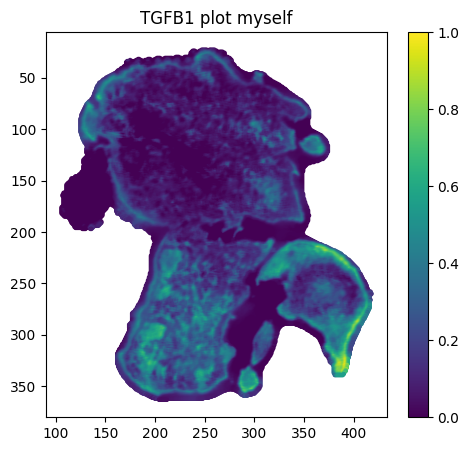

In [64]:
fig, ax = plt.subplots(1, 1, figsize=(5.5, 5))
plot = ax.scatter(locs[:,1], locs[:,0], c=cnts, s=5)    
ax.set_title(str(gene_names[0]) + ' plot myself')
cbar = fig.colorbar(plot, ax=ax)
ax.invert_yaxis()
# plt.savefig("P1_pixel.pdf", format="pdf")
plt.gcf().set_dpi(100)
plt.show()

## Plot spot level expression

In [65]:
import os
os.chdir(str(path)+'iSTAR/istar-master/data/NPC1/')

In [66]:
def load_tsv(filename, index=True):
    if index:
        index_col = 0
    else:
        index_col = None
    df = pd.read_csv(filename, sep='\t', header=0, index_col=index_col)
    print(f'Dataframe loaded from {filename}')
    return df

def read_string(filename):
    return read_lines(filename)[0]


from PIL import Image
Image.MAX_IMAGE_PIXELS = None
def load_image(filename, verbose=True):
    img = Image.open(filename)
    img = np.array(img)
    if img.ndim == 3 and img.shape[-1] == 4:
        img = img[..., :3]  # remove alpha channel
    if verbose:
        print(f'Image loaded from {filename}')
    return img

In [67]:
factor = 16

infile_cnts = 'cnts.tsv'
infile_locs = 'locs.tsv'
infile_img = 'he.jpg'
infile_genes = 'gene-names.txt'
infile_radius = 'radius.txt'

# load data
cnts = load_tsv(infile_cnts)
locs = load_tsv(infile_locs)

Dataframe loaded from cnts.tsv
Dataframe loaded from locs.tsv


In [68]:
cnts.index

Index(['AAACAATCTACTAGCA-1', 'AAACGAAGAACATACC-1', 'AAAGGGATGTAGCAAG-1',
       'AAAGTCACTGATGTAA-1', 'AAAGTGTGATTTATCT-1', 'AAAGTTGACTCCCGTA-1',
       'AAATCGTGTACCACAA-1', 'AAATGCTCGTTACGTT-1', 'AAATGGCATGTCTTGT-1',
       'AAATGGTCAATGTGCC-1',
       ...
       'TTGGGCGGCGGTTGCC-1', 'TTGGTCACACTCGTAA-1', 'TTGTAATCCGTACTCG-1',
       'TTGTATCACACAGAAT-1', 'TTGTCGTTCAGTTACC-1', 'TTGTGGCCCTGACAGT-1',
       'TTGTGTTTCCCGAAAG-1', 'TTGTTAGCAAATTCGA-1', 'TTGTTCAGTGTGCTAC-1',
       'TTGTTTGTGTAAATTC-1'],
      dtype='object', name='cellID', length=1331)

In [69]:
locs.index

Index(['AAACAATCTACTAGCA-1', 'AAACGAAGAACATACC-1', 'AAAGGGATGTAGCAAG-1',
       'AAAGTCACTGATGTAA-1', 'AAAGTGTGATTTATCT-1', 'AAAGTTGACTCCCGTA-1',
       'AAATCGTGTACCACAA-1', 'AAATGCTCGTTACGTT-1', 'AAATGGCATGTCTTGT-1',
       'AAATGGTCAATGTGCC-1',
       ...
       'TTGGGCGGCGGTTGCC-1', 'TTGGTCACACTCGTAA-1', 'TTGTAATCCGTACTCG-1',
       'TTGTATCACACAGAAT-1', 'TTGTCGTTCAGTTACC-1', 'TTGTGGCCCTGACAGT-1',
       'TTGTGTTTCCCGAAAG-1', 'TTGTTAGCAAATTCGA-1', 'TTGTTCAGTGTGCTAC-1',
       'TTGTTTGTGTAAATTC-1'],
      dtype='object', name='spot', length=1331)

In [70]:
## 检查 `cnts` 和 `locs` 数据是否具有相同的索引
## 通过比较它们的索引（`cnts.index` 和 `locs.index`）并确保它们相等来实现的
## 如果索引不相等，则 `assert` 语句将引发一个异常，指示数据之间存在不匹配。
assert (cnts.index == locs.index).all()
spot_radius = int(read_string(infile_radius))
img = load_image(infile_img)

Image loaded from he.jpg


In [71]:
if img.dtype == bool:
    img = img.astype(np.uint8) * 255
if img.ndim == 2:
    img = np.tile(img[..., np.newaxis], 3)

In [72]:
print("infile_cnts shape:\n", cnts.shape)
print("infile_locs shape:\n", locs.shape)
print("spot_radius:\n", spot_radius)

infile_cnts shape:
 (1331, 36601)
infile_locs shape:
 (1331, 2)
spot_radius:
 100


In [73]:
## select genes
gene_names = read_lines(infile_genes)
# print("gene_names:\n", gene_names)
cnts = cnts[gene_names]
# print("cnts:\n", cnts)
cnts

,TGFB1,TGFBR1,TGFBR2,TGFB2,TGFB3,ACVR1B,ACVR1C,ACVR1,BMP2,BMPR1A,...,KDR,TREM2,SEMA6A,SEMA6B,SEMA7A,PLXNC1,SIGLEC1,THY1,VCAM1,VSIR
cellID,,,,,,,,,,,,,,,,,,,,,
AAACAATCTACTAGCA-1,0,0,0,0,1,1,0,0,0,0,...,0,1,0,0,0,0,0,0,0,0
AAACGAAGAACATACC-1,3,0,0,0,0,0,0,1,0,0,...,0,0,1,0,0,0,1,0,2,0
AAAGGGATGTAGCAAG-1,0,1,0,0,0,1,0,0,0,0,...,0,0,0,0,0,0,0,1,5,1
AAAGTCACTGATGTAA-1,0,1,0,0,0,2,0,0,0,0,...,0,0,1,0,0,0,1,0,4,1
AAAGTGTGATTTATCT-1,1,0,3,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,1,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
TTGTGGCCCTGACAGT-1,0,0,0,0,0,0,0,1,0,1,...,0,0,0,0,1,0,0,0,1,1
TTGTGTTTCCCGAAAG-1,2,0,0,0,0,0,0,0,0,0,...,0,0,0,0,1,1,0,1,1,2
TTGTTAGCAAATTCGA-1,1,1,0,0,0,1,0,1,1,0,...,0,0,1,0,0,0,0,0,6,1


In [74]:
cnts_numpy = cnts.to_numpy()
print("cnts:\n", cnts_numpy)

cnts:
 [[0 0 0 ... 0 0 0]
 [3 0 0 ... 0 2 0]
 [0 1 0 ... 1 5 1]
 ...
 [1 1 0 ... 0 6 1]
 [1 0 0 ... 0 2 0]
 [1 0 0 ... 0 1 2]]


In [75]:
## recale image
locs = locs.astype(float)
locs = np.stack([locs['y'], locs['x']], -1)
print("locs:\n", locs)
locs /= factor
locs = locs.round().astype(int)
print("locs:\n", locs)

from einops import reduce
img = reduce(
        img.astype(float), '(h1 h) (w1 w) c -> h1 w1 c', 'mean',
        h=factor, w=factor).astype(np.uint8)

locs:
 [[ 994. 3248.]
 [1277. 4373.]
 [2956. 4262.]
 ...
 [2767. 3189.]
 [2956. 4368.]
 [1368. 3676.]]
locs:
 [[ 62 203]
 [ 80 273]
 [185 266]
 ...
 [173 199]
 [185 273]
 [ 86 230]]


In [76]:
print(locs.max())
print(locs.min())

414
45


In [77]:
## rescale spot
spot_radius = np.round(spot_radius / factor).astype(int)    # 100/16
print("spot_radius:\n", spot_radius)

##  `plot_spots_show` 函数中，点（像素）的大小由变量 `radius` 控制
## define spot_radius by myself
spot_radius = 3
print("spot_radius:\n", spot_radius)

spot_radius:
 6
spot_radius:
 3


In [78]:
def get_disk_mask(radius, boundary_width=None):
    radius_ceil = np.ceil(radius).astype(int)
    locs = np.meshgrid(
            np.arange(-radius_ceil, radius_ceil+1),
            np.arange(-radius_ceil, radius_ceil+1),
            indexing='ij')
    locs = np.stack(locs, -1)
    distsq = (locs**2).sum(-1)
    isin = distsq <= radius**2
    if boundary_width is not None:
        isin *= distsq >= (radius-boundary_width)**2
    return isin

def save_image(img, filename):
    # mkdir(filename)
    Image.fromarray(img).save(filename)
    print(filename)

import matplotlib.pyplot as plt
def plot_spots(
        img, cnts, locs, radius, outfile, cmap='magma',
        weight=0.8, disk_mask=True, standardize_img=False):
    cnts = cnts.astype(np.float32)

    img = img.astype(np.float32)
    img /= 255.0

    if standardize_img:
        if np.isclose(0.0, np.nanstd(img, (0, 1))).all():
            img[:] = 1.0
        else:
            img -= np.nanmin(img)
            img /= np.nanmax(img) + 1e-12

    cnts -= np.nanmin(cnts)
    cnts /= np.nanmax(cnts) + 1e-12

    cmap = plt.get_cmap(cmap)
    if disk_mask:
        mask_patch = get_disk_mask(radius)
    else:
        mask_patch = np.ones((radius*2, radius*2)).astype(bool)
    indices_patch = np.stack(np.where(mask_patch), -1)
    indices_patch -= radius
    for ij, ct in zip(locs, cnts):
        color = np.array(cmap(ct)[:3])
        indices = indices_patch + ij
        img[indices[:, 0], indices[:, 1]] *= 1 - weight
        img[indices[:, 0], indices[:, 1]] += color * weight
    img = (img * 255).astype(np.uint8)
    save_image(img, outfile)     ## LLY
    # return img     ## LLY

def plot_spots_show(
        img, cnts, locs, radius, outfile, cmap='magma',
        weight=0.8, disk_mask=True, standardize_img=False):
    cnts = cnts.astype(np.float32)

    img = img.astype(np.float32)
    img /= 255.0

    if standardize_img:
        if np.isclose(0.0, np.nanstd(img, (0, 1))).all():
            img[:] = 1.0
        else:
            img -= np.nanmin(img)
            img /= np.nanmax(img) + 1e-12

    cnts -= np.nanmin(cnts)
    cnts /= np.nanmax(cnts) + 1e-12

    cmap = plt.get_cmap(cmap)
    if disk_mask:
        mask_patch = get_disk_mask(radius)
    else:
        mask_patch = np.ones((radius*2, radius*2)).astype(bool)
    indices_patch = np.stack(np.where(mask_patch), -1)
    indices_patch -= radius
    for ij, ct in zip(locs, cnts):
        color = np.array(cmap(ct)[:3])
        indices = indices_patch + ij
        img[indices[:, 0], indices[:, 1]] *= 1 - weight
        img[indices[:, 0], indices[:, 1]] += color * weight
    img = (img * 255).astype(np.uint8)
    # save_image(img, outfile)     ## LLY
    return img     ## LLY

In [79]:
# radius=spot_radius
# disk_mask=True
# prefix=str(path)+'iSTAR/istar-master/data/NPC1/spots/'

# for i, gname in enumerate(gene_names):
#     ct = cnts_numpy[:, i]
#     outfile = str(prefix)+str(gname)+'.png'
#     image = plot_spots(
#             img=img, cnts=ct, locs=locs, radius=radius,
#             cmap='turbo', weight=1.0,
#             disk_mask=disk_mask,
#             outfile=outfile)

# # Image.fromarray(image)    ## LLY

In [81]:
cnts_numpy[:, 0]

array([0, 3, 0, ..., 1, 1, 1])

In [86]:
np.array(cnts["TGFB1"])

array([0, 3, 0, ..., 1, 1, 1])

In [138]:
# ct = cnts_numpy[:, 0]
gene = 'CD70'
ct = np.array(cnts[str(gene)])
print("ct shape:", ct.shape)

radius=spot_radius
disk_mask=True
prefix=str(path)+'iSTAR/istar-master/data/NPC1/spots/'
outfile = str(prefix)+str(gene)+'.png'
image = plot_spots_show(
        img=img, cnts=ct, locs=locs, radius=radius,
        cmap='turbo', weight=1.0,
        disk_mask=disk_mask,
        outfile=outfile)
Image.fromarray(image)    ## LLY

IndexError: only integers, slices (`:`), ellipsis (`...`), numpy.newaxis (`None`) and integer or boolean arrays are valid indices

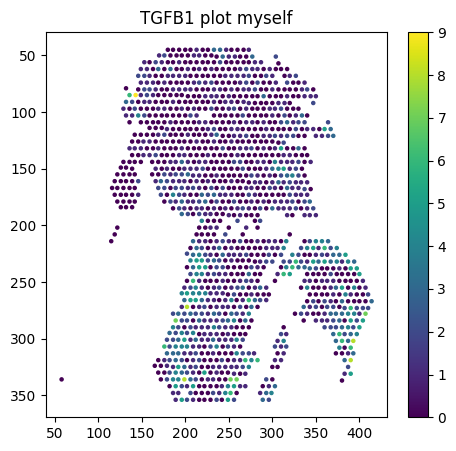

In [94]:
fig, ax = plt.subplots(1, 1, figsize=(5.5, 5))
plot_spot = ax.scatter(locs[:,1], locs[:,0], c=ct, s=5)    
ax.set_title(str(gene_names[0]) + ' plot myself')
cbar = fig.colorbar(plot_spot, ax=ax)
ax.invert_yaxis()
# plt.savefig("P1_spot.pdf", format="pdf")
plt.gcf().set_dpi(100)
plt.show()

## Order the position and obtain the expression (matched spot)

In [95]:
## adaress loc0, according to locs
factor = 16
locs_spot = load_tsv("locs.tsv")
locs_spot = locs_spot.astype(float)
locs_spot = np.stack([locs_spot['y'], locs_spot['x']], -1)
# print("locs:\n", locs_spot)
locs_spot /= factor
locs_spot = locs_spot.round().astype(int)
print("locs_spot:\n", locs_spot)
print("locs_spot shape:", locs_spot.shape)
print("locs_spot.max():", locs_spot.max())
print("locs_spot.min():", locs_spot.min())

Dataframe loaded from locs.tsv
locs_spot:
 [[ 62 203]
 [ 80 273]
 [185 266]
 ...
 [173 199]
 [185 273]
 [ 86 230]]
locs_spot shape: (1331, 2)
locs_spot.max(): 414
locs_spot.min(): 45


In [96]:
gene_names = read_lines('gene-names.txt')
cnts = load_pickle('cnts-super/'+str(gene_names[0])+'.pickle')
cnts[~mask] = np.nan
x = cnts.copy()

## another plot method
cnts_pixel = []
locs_pixel = []
for i in range(x.shape[0]):
    for j in range(x.shape[1]):
        color = x[i, j]
        if not np.isnan(color):
            cnts_pixel.append(color)
            locs_pixel.append([i, j])

locs_pixel = np.array(locs_pixel)
cnts_pixel = np.array(cnts_pixel)
print(locs_pixel.shape)
locs_pixel

Pickle loaded from cnts-super/TGFB1.pickle
(66440, 2)


array([[ 23, 247],
       [ 23, 248],
       [ 23, 249],
       ...,
       [363, 210],
       [363, 211],
       [363, 212]])

In [97]:
from scipy.spatial import cKDTree
tree = cKDTree(locs_pixel)
print(tree)
_, closest_points_indices = tree.query(locs_spot, k=1)
print(len(closest_points_indices))
locs_order = locs_pixel[closest_points_indices]
print(locs_order.shape)
locs_order

1331
(1331, 2)


array([[ 62, 203],
       [ 80, 273],
       [185, 266],
       ...,
       [173, 199],
       [185, 273],
       [ 86, 230]])

[0.00136393 0.00182579 0.0024089  ... 0.00236566 0.00513018 0.00275143]
(1331,)


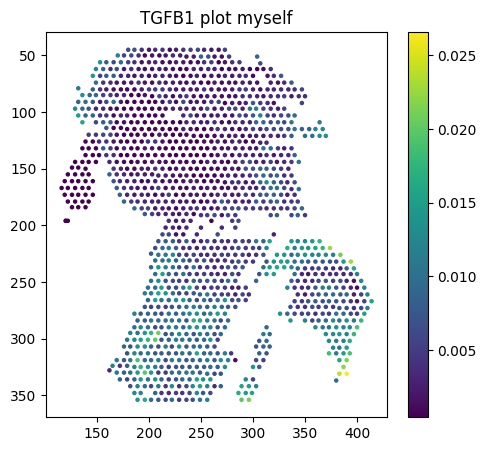

In [98]:
## order on gene expression according to cnts_order
cots_order = []
for loc in locs_order:
    i, j = loc
    value = x[i, j]
    cots_order.append(value)
    
cots_order = np.array(cots_order)
print(cots_order)
print(cots_order.shape)

## plot
fig, ax = plt.subplots(1, 1, figsize=(5.5, 5))
plot_spot = ax.scatter(locs_order[:,1], locs_order[:,0], c=cots_order, s=5)    
ax.set_title(str(gene_names[0]) + ' plot myself')
cbar = fig.colorbar(plot_spot, ax=ax)
ax.invert_yaxis()
# plt.savefig("P1_spot.pdf", format="pdf")
plt.gcf().set_dpi(100)
plt.show()

In [99]:
## cycle all 10 gene

gene_names = read_lines('gene-names.txt')

import numpy as np
import pandas as pd

cnts_order_gene = []
for gn in gene_names:
    cnts = load_pickle('cnts-super/' + str(gn) + '.pickle')
    cnts[~mask] = np.nan
    x = cnts.copy()

    cots_order = []
    for loc in locs_order:
        i, j = loc
        value = x[i, j]
        cots_order.append(value)
    cots_order = np.array(cots_order)
    cnts_order_gene.append(cots_order)

cnts_order_gene = np.column_stack(cnts_order_gene)
cnts_order_gene = pd.DataFrame(cnts_order_gene, columns=gene_names)

print(cnts_order_gene.shape)
# cnts_order_gene

Pickle loaded from cnts-super/TGFB1.pickle
Pickle loaded from cnts-super/TGFBR1.pickle
Pickle loaded from cnts-super/TGFBR2.pickle
Pickle loaded from cnts-super/TGFB2.pickle
Pickle loaded from cnts-super/TGFB3.pickle
Pickle loaded from cnts-super/ACVR1B.pickle
Pickle loaded from cnts-super/ACVR1C.pickle
Pickle loaded from cnts-super/ACVR1.pickle
Pickle loaded from cnts-super/BMP2.pickle
Pickle loaded from cnts-super/BMPR1A.pickle
Pickle loaded from cnts-super/ACVR2A.pickle
Pickle loaded from cnts-super/ACVR2B.pickle
Pickle loaded from cnts-super/BMPR2.pickle
Pickle loaded from cnts-super/BMP4.pickle
Pickle loaded from cnts-super/GDF7.pickle
Pickle loaded from cnts-super/BMP6.pickle
Pickle loaded from cnts-super/BMP7.pickle
Pickle loaded from cnts-super/BMP8A.pickle
Pickle loaded from cnts-super/BMP8B.pickle
Pickle loaded from cnts-super/ACVRL1.pickle
Pickle loaded from cnts-super/GDF11.pickle
Pickle loaded from cnts-super/GDF15.pickle
Pickle loaded from cnts-super/AMH.pickle
Pickle loa

,TGFB1,TGFBR1,TGFBR2,TGFB2,TGFB3,ACVR1B,ACVR1C,ACVR1,BMP2,BMPR1A,...,KDR,TREM2,SEMA6A,SEMA6B,SEMA7A,PLXNC1,SIGLEC1,THY1,VCAM1,VSIR
0,0.001364,0.001163,0.000566,0.000082,0.000368,0.003092,0.000153,0.000285,0.000366,0.000325,...,0.000399,0.000564,0.002197,0.000162,0.000309,0.000411,0.000487,0.001260,0.008607,0.002346
1,0.001826,0.001472,0.000566,0.000082,0.000374,0.003506,0.000150,0.000587,0.000245,0.000368,...,0.000400,0.000761,0.001509,0.000162,0.000317,0.000412,0.000815,0.000740,0.007873,0.003096
2,0.002409,0.001978,0.000551,0.000092,0.000368,0.004431,0.000147,0.000658,0.001434,0.000839,...,0.000393,0.000243,0.003060,0.000161,0.000323,0.001099,0.000548,0.004213,0.022234,0.004646
3,0.003394,0.001207,0.002858,0.000080,0.000185,0.000924,0.000146,0.000420,0.000245,0.000323,...,0.000395,0.000248,0.000639,0.000165,0.000458,0.000852,0.000781,0.004287,0.006269,0.006243
4,0.012744,0.004042,0.017389,0.000074,0.000878,0.000362,0.000146,0.001178,0.000245,0.000674,...,0.000390,0.000229,0.000241,0.000947,0.003512,0.004569,0.000440,0.011617,0.015379,0.013138
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1326,0.000852,0.000646,0.000560,0.000079,0.000164,0.001415,0.000147,0.000245,0.000247,0.000324,...,0.000397,0.000240,0.001466,0.000164,0.000321,0.000407,0.000341,0.003336,0.005905,0.002622
1327,0.011815,0.004984,0.010898,0.000081,0.001177,0.000411,0.000142,0.001998,0.000245,0.001506,...,0.000382,0.000350,0.000243,0.000628,0.004868,0.003201,0.001098,0.009159,0.016343,0.012190
1328,0.002366,0.001867,0.000552,0.000081,0.000164,0.002664,0.000145,0.000726,0.002677,0.000329,...,0.000395,0.000243,0.004380,0.000164,0.000327,0.000800,0.000419,0.004815,0.031694,0.004283
1329,0.005130,0.001480,0.006337,0.000077,0.000473,0.000395,0.000146,0.000246,0.000239,0.000325,...,0.000395,0.000238,0.000242,0.000397,0.001612,0.001277,0.000330,0.004831,0.002450,0.006683


In [109]:
cnts_order_gene.insert(0, 'cellID', cellID)  # 插入cellID
cnts_order_gene.head()

,cellID,TGFB1,TGFBR1,TGFBR2,TGFB2,TGFB3,ACVR1B,ACVR1C,ACVR1,BMP2,...,KDR,TREM2,SEMA6A,SEMA6B,SEMA7A,PLXNC1,SIGLEC1,THY1,VCAM1,VSIR
0,AAACAATCTACTAGCA-1,0.001364,0.001163,0.000566,0.000082,0.000368,0.003092,0.000153,0.000285,0.000366,...,0.000399,0.000564,0.002197,0.000162,0.000309,0.000411,0.000487,0.001260,0.008607,0.002346
1,AAACGAAGAACATACC-1,0.001826,0.001472,0.000566,0.000082,0.000374,0.003506,0.000150,0.000587,0.000245,...,0.000400,0.000761,0.001509,0.000162,0.000317,0.000412,0.000815,0.000740,0.007873,0.003096
2,AAAGGGATGTAGCAAG-1,0.002409,0.001978,0.000551,0.000092,0.000368,0.004431,0.000147,0.000658,0.001434,...,0.000393,0.000243,0.003060,0.000161,0.000323,0.001099,0.000548,0.004213,0.022234,0.004646
3,AAAGTCACTGATGTAA-1,0.003394,0.001207,0.002858,0.000080,0.000185,0.000924,0.000146,0.000420,0.000245,...,0.000395,0.000248,0.000639,0.000165,0.000458,0.000852,0.000781,0.004287,0.006269,0.006243
4,AAAGTGTGATTTATCT-1,0.012744,0.004042,0.017389,0.000074,0.000878,0.000362,0.000146,0.001178,0.000245,...,0.000390,0.000229,0.000241,0.000947,0.003512,0.004569,0.000440,0.011617,0.015379,0.013138


In [110]:
## save the expression profile of istar
# cnts_order_gene.to_csv('istar_predict_expression.tsv', sep='\t', index=False)

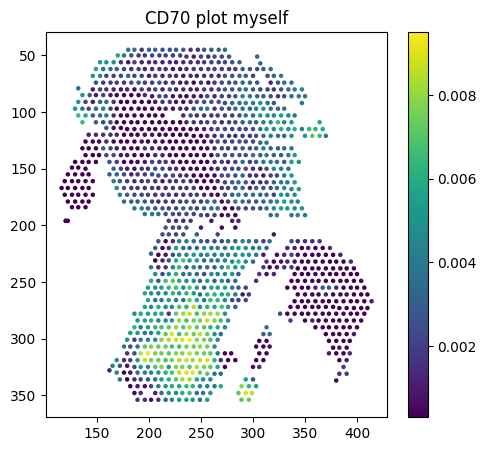

In [103]:
## plot in spot level

# gene = 'CD70'
fig, ax = plt.subplots(1, 1, figsize=(5.5, 5))
plot_spot = ax.scatter(locs_order[:,1], locs_order[:,0], c=cnts_order_gene[str(gene)], s=5)    
ax.set_title(str(gene) + ' plot myself')
cbar = fig.colorbar(plot_spot, ax=ax)
ax.invert_yaxis()
# plt.savefig("P1_spot.pdf", format="pdf")
plt.gcf().set_dpi(100)
plt.show()

In [141]:
# import tensorflow as tf
# tf.image.ssim(plot_spot, plot_spot, 255)

## get LRgene-names.txt 

In [104]:
len(matrix1.columns)

36602

In [4]:
## Load LR gene
LRgene = pd.read_csv(str(path)+'iSTAR/human_breast_Xenium/LRgene_CellChatDB_baseline.csv')


## NPC1 selected gene
patientxy = 'patient1'
os.chdir(str(path)+'NPC/Data/stdata/ImputData/'+str(patientxy)+'/')
npc1_pixel = sc.read_h5ad(filename=str(patientxy)+'_adata_all.h5ad')
print(npc1_pixel)
feature_names = np.array(npc1_pixel.var.index.astype("str"))
print("feature_names shape: ", len(feature_names)) 

lr_gene_list = LRgene['LR gene'].tolist()
available_genes = pd.DataFrame([gene for gene in lr_gene_list if gene in feature_names])
print(available_genes.shape)

# available_genes.to_csv("LRgene-names.txt", sep='\t', index=False, header=False)

AnnData object with n_obs × n_vars = 80624 × 596
    obs: 'x', 'y', 'CD27'
feature_names shape:  596
(596, 1)


In [6]:
# feature_names

## compare with original data

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from scipy.stats import pearsonr
from scipy.spatial.distance import jensenshannon

def load_tsv(filename, index=True):
    index_col = 0 if index else None
    df = pd.read_csv(filename, sep='\t', header=0, index_col=index_col)
    print(f'Dataframe loaded from {filename}')
    return df

def load_image(filename, verbose=True):
    img = Image.open(filename)
    img = np.array(img)
    if img.ndim == 3 and img.shape[-1] == 4:
        img = img[..., :3]  # remove alpha channel
    if verbose:
        print(f'Image loaded from {filename}')
    return img

def compute_jsd_between_matrices(matrix1, matrix2, axis=0):
    probabilities1 = matrix1 / np.sum(matrix1, axis=axis, keepdims=True)
    probabilities2 = matrix2 / np.sum(matrix2, axis=axis, keepdims=True)
    jsd = np.zeros(matrix1.shape[1 - axis])
    for i in range(matrix1.shape[1 - axis]):
        p, q = (probabilities1[:, i], probabilities2[:, i]) if axis == 0 else (probabilities1[i, :], probabilities2[i, :])
        jsd[i] = jensenshannon(p, q)
    return jsd

def rmse(y_pred, y_mean_pred):
    mse = ((y_mean_pred - y_pred)**2).mean()
    return mse**0.5

In [13]:
## Read in gene expression and spatial location
import os
os.chdir(str(path)+'iSTAR/istar-master/data/NPC1/')

visium_adata = load_tsv('cnts.tsv')
print(visium_adata.shape)
pixel_adata = load_tsv('istar_predict_expression.tsv', )
print(pixel_adata.shape)

Dataframe loaded from cnts.tsv
(1331, 36601)
Dataframe loaded from istar_predict_expression.tsv
(1331, 596)


shared_genes:  596
shared_barcodes shape:  (1331,)
shared_xenium_df shape:  (1331, 596)
shared_visium_df shape:  (1331, 596)
corr, p_value:  0.5657734995770078 1.7645752410836157e-113


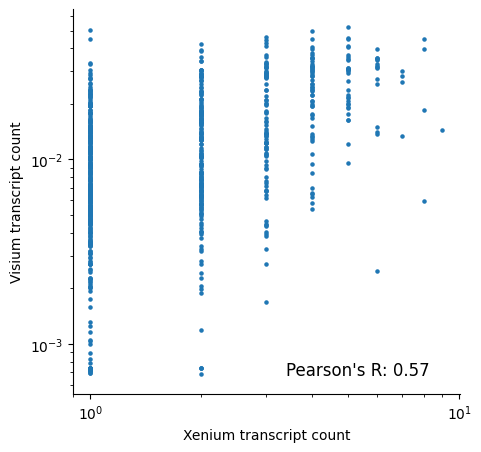

In [17]:
## Data setup
## Collating both interpolated Visium spots and actual Visium spots
## The Xenium and Visium gene sets differ; here we are filtering the two data frames to
## ensure they share the exact same genes. In addition, we can only interpolate Visium spot counts for
## which we have Xenium data. We remove all spots which do not overlap between the two modalities.
xenium_df = pixel_adata
visium_df = visium_adata
shared_barcodes = xenium_df.index.intersection(visium_df.index)
# shared_genes = xenium_df.columns.intersection(feature_names)
# print("shared_genes: ", shared_genes.shape)
shared_genes = sorted(list(xenium_df.columns.intersection(feature_names)), key=feature_names.tolist().index)
print("shared_genes: ", len(shared_genes))

shared_xenium_df = xenium_df.loc[shared_barcodes, shared_genes]
shared_visium_df = visium_df.loc[shared_barcodes, shared_genes]
print("shared_barcodes shape: ", shared_barcodes.shape)
print("shared_xenium_df shape: ", shared_xenium_df.shape)
print("shared_visium_df shape: ", shared_visium_df.shape)


## selected gene
# Gene = "TACSTD2"
Gene = "CD27"
# Gene = "CD70"
corr, p_value = pearsonr(shared_visium_df[Gene], shared_xenium_df[Gene])
print("corr, p_value: ", corr, p_value)

## Plot style setup
fig = plt.figure(figsize=(5,5))
ax = plt.gca()

## Plotting code
ax.scatter(shared_visium_df[Gene], shared_xenium_df[Gene], s=5)
ax.set_xscale("log")
ax.set_yscale("log")

## Plot style adjustments
ax.set_xlabel("Xenium transcript count")
ax.set_ylabel("Visium transcript count")
ax.spines.right.set_visible(False)
ax.spines.top.set_visible(False)
ax.yaxis.set_ticks_position("left")
ax.xaxis.set_ticks_position("bottom")

## Add Pearson correlation coefficient and p-value to the plot
# ax.annotate(f"Pearson's R: {corr:.2f}\nP-value: {p_value:.2e}", xy=(0.05, 0.95), xycoords="axes fraction", fontsize=12)
ax.annotate(f"Pearson's R: {corr:.2f}", xy=(0.55, 0.05), xycoords="axes fraction", fontsize=12)
plt.show()

In [19]:
# shared_genes

In [23]:
rmse_istar = rmse(shared_visium_df, shared_xenium_df)
print(rmse_istar)
## save rmse
# rmse_istar.to_csv("rmse_iStar.csv")  

TGFB1      1.132745
TGFBR1     0.654103
TGFBR2     1.036870
TGFB2      0.122549
TGFB3      0.315786
             ...   
PLXNC1     0.519088
SIGLEC1    0.362343
THY1       1.159541
VCAM1      2.876266
VSIR       1.313817
Length: 596, dtype: float64


In [21]:
####################################
# 2024.13.9 add row names
####################################
shared_visium_np = shared_visium_df.to_numpy()
shared_xenium_np = shared_xenium_df.to_numpy()
FineST_spot_JSD_subspot_np = compute_jsd_between_matrices(shared_xenium_np, shared_visium_np, axis=1)
FineST_spot_JSD_subspot = pd.DataFrame(FineST_spot_JSD_subspot_np, columns=['iStar_JSD'])
FineST_spot_JSD_subspot.index = np.array(shared_xenium_df.index)
FineST_gene_JSD_subspot_np = compute_jsd_between_matrices(shared_xenium_np, shared_visium_np, axis=0)
FineST_gene_JSD_subspot = pd.DataFrame(FineST_gene_JSD_subspot_np, columns=['iStar_JSD'])
FineST_gene_JSD_subspot.index = np.array(shared_xenium_df.columns)

print(FineST_spot_JSD_subspot.head())
print(FineST_spot_JSD_subspot['iStar_JSD'].mean())
print(FineST_gene_JSD_subspot.head())
print(FineST_gene_JSD_subspot['iStar_JSD'].mean())

                    iStar_JSD
AAACAATCTACTAGCA-1   0.366104
AAACGAAGAACATACC-1   0.376250
AAAGGGATGTAGCAAG-1   0.292893
AAAGTCACTGATGTAA-1   0.342683
AAAGTGTGATTTATCT-1   0.297894
0.3636616867185351
        iStar_JSD
TGFB1    0.464710
TGFBR1   0.604268
TGFBR2   0.504832
TGFB2    0.792687
TGFB3    0.712701
0.6329724308053244


In [22]:
## save JSD
# import os
# os.chdir(str(path)+'iSTAR/istar-master/data/NPC1/')
# FineST_spot_JSD_subspot.to_csv("JSDspot_istar.csv")   
# FineST_gene_JSD_subspot.to_csv("JSDgene_istar.csv")   

rmse_values:  TGFB1      1.132745
TGFBR1     0.654103
TGFBR2     1.036870
TGFB2      0.122549
TGFB3      0.315786
             ...   
PLXNC1     0.519088
SIGLEC1    0.362343
THY1       1.159541
VCAM1      2.876266
VSIR       1.313817
Length: 596, dtype: float64


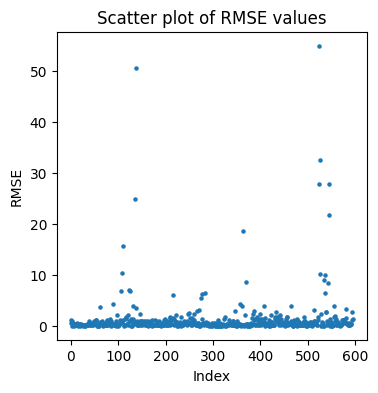

In [24]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 计算每列的 RMSE
rmse_values = np.sqrt(np.mean((shared_visium_df - shared_xenium_df)**2, axis=0))
print("rmse_values: ", rmse_values)

# 生成 RMSE 值的索引
rmse_indices = np.arange(len(rmse_values))

# 绘制散点图
plt.figure(figsize=(4, 4))
plt.scatter(rmse_indices, rmse_values, s=5)
plt.title("Scatter plot of RMSE values")
plt.xlabel("Index")
plt.ylabel("RMSE")
plt.show()

In [25]:
print(np.max(rmse_values))
print(np.argmax(rmse_values))
print(rmse_values)
feature_names[np.argmax(rmse_values)]

55.03411470415907
524
TGFB1      1.132745
TGFBR1     0.654103
TGFBR2     1.036870
TGFB2      0.122549
TGFB3      0.315786
             ...   
PLXNC1     0.519088
SIGLEC1    0.362343
THY1       1.159541
VCAM1      2.876266
VSIR       1.313817
Length: 596, dtype: float64


'HLA-B'

corr, p_value:  0.7518446586976711 1.1491834581499067e-242


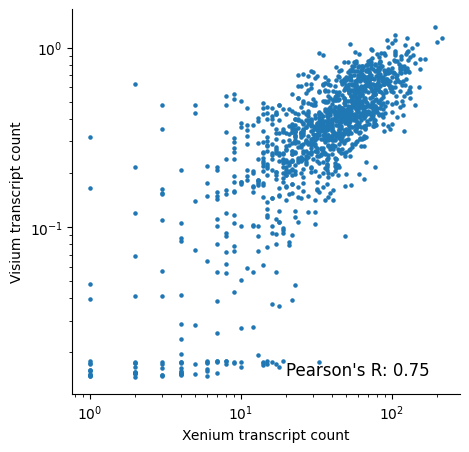

In [26]:
Gene = feature_names[np.argmax(rmse_values)]

## Calculate Pearson correlation coefficient and p-value
corr, p_value = pearsonr(shared_visium_df[Gene], shared_xenium_df[Gene])
print("corr, p_value: ", corr, p_value)

## Plot style setup
fig = plt.figure(figsize=(5,5))
ax = plt.gca()

## Plotting code
ax.scatter(shared_visium_df[Gene], shared_xenium_df[Gene], s=5)
ax.set_xscale("log")
ax.set_yscale("log")

## Plot style adjustments
ax.set_xlabel("Xenium transcript count")
ax.set_ylabel("Visium transcript count")
ax.spines.right.set_visible(False)
ax.spines.top.set_visible(False)
ax.yaxis.set_ticks_position("left")
ax.xaxis.set_ticks_position("bottom")

## Add Pearson correlation coefficient and p-value to the plot
# ax.annotate(f"Pearson's R: {corr:.2f}\nP-value: {p_value:.2e}", xy=(0.05, 0.95), xycoords="axes fraction", fontsize=12)
ax.annotate(f"Pearson's R: {corr:.2f}", xy=(0.55, 0.05), xycoords="axes fraction", fontsize=12)
plt.show()

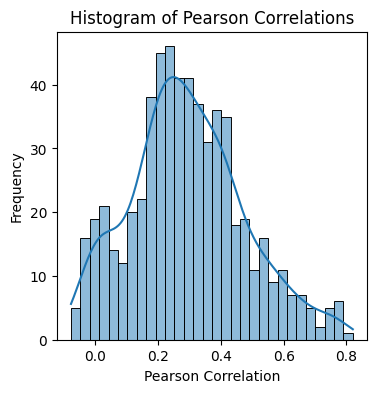

In [27]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 计算每列的皮尔逊相关系数
pearson_correlations = shared_visium_df.corrwith(shared_xenium_df)

# 绘制频率直方图
plt.figure(figsize=(4, 4))
sns.histplot(data=pearson_correlations, bins=30, kde=True)
plt.title("Histogram of Pearson Correlations")
plt.xlabel("Pearson Correlation")
plt.ylabel("Frequency")
plt.show()

In [28]:
import pandas as pd
from scipy.stats import pearsonr

# 计算每一列的Pearson相关系数和p值
columns_corr = []
columns_p_value = []
for column in shared_visium_df.columns:
    corr, p_value = pearsonr(shared_visium_df[column], shared_xenium_df[column])
    columns_corr.append(corr)
    columns_p_value.append(p_value)

# 计算每一行的Pearson相关系数和p值
rows_corr = []
rows_p_value = []
for idx, row in shared_visium_df.iterrows():
    corr, p_value = pearsonr(row, shared_xenium_df.loc[idx])
    rows_corr.append(corr)
    rows_p_value.append(p_value)

# 保存结果到dataframe
columns_result_df = pd.DataFrame({'Gene': shared_visium_df.columns, 'correlation_coefficient': columns_corr, 'p_value': columns_p_value})
rows_result_df = pd.DataFrame({'Sample': shared_visium_df.index, 'correlation_coefficient': rows_corr, 'p_value': rows_p_value})

print("columns_result_df: \n", columns_result_df)
print("rows_result_df: \n", rows_result_df)

columns_result_df: 
         Gene  correlation_coefficient       p_value
0      TGFB1                 0.471325  1.469319e-74
1     TGFBR1                 0.252077  9.717614e-21
2     TGFBR2                 0.507945  3.263178e-88
3      TGFB2                 0.143345  1.505617e-07
4      TGFB3                 0.226935  5.245727e-17
..       ...                      ...           ...
591   PLXNC1                 0.268718  1.893170e-23
592  SIGLEC1                 0.156018  1.054660e-08
593     THY1                 0.387820  5.141323e-49
594    VCAM1                 0.528980  7.685121e-97
595     VSIR                 0.421533  1.797785e-58

[596 rows x 3 columns]
rows_result_df: 
                   Sample  correlation_coefficient        p_value
0     AAACAATCTACTAGCA-1                 0.944102  1.842457e-288
1     AAACGAAGAACATACC-1                 0.930464  3.339684e-261
2     AAAGGGATGTAGCAAG-1                 0.970424   0.000000e+00
3     AAAGTCACTGATGTAA-1                 0.955834  4.

In [30]:
## save correlation
# columns_result_df.to_csv("cor_iStar_Gene.csv")    
# rows_result_df.to_csv("cor_iStar_Sample.csv")  